In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import websocket_transfer.capture as cap

async def print_term(term):
    # An image when a tsncd page is open, the text form when there is none.
    return await cap.capture_morphism(term)

# 1.1.1 Autoalignment

Requesting render from server...
Received from server: {"msgType": "Connected"}


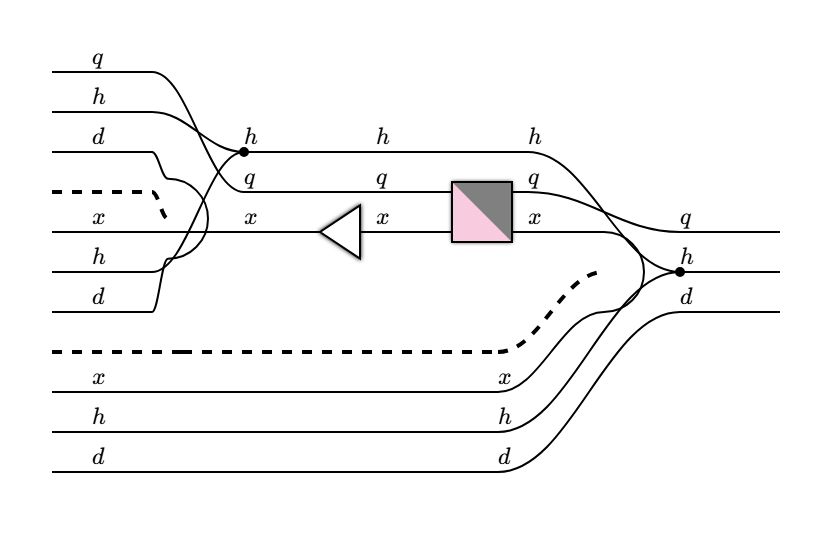

In [3]:
import construction_helpers as ch # Required for overloaded operators
import data_structure.Category as cat
import data_structure.Operators as ops

qk_matmul = ops.Einops.template('q h d, x h d -> h q x')
softmax = ops.SoftMax.template()
mask = ops.WeightedTriangularLower.template()
sv_matmul = ops.Einops.template('h q x, x h d -> q h d')
attention_core = qk_matmul @ softmax @ mask @ sv_matmul
await print_term(attention_core)

# 1.1.2 Configuration Generation

Requesting render from server...
Received from server: {"msgType": "Connected"}


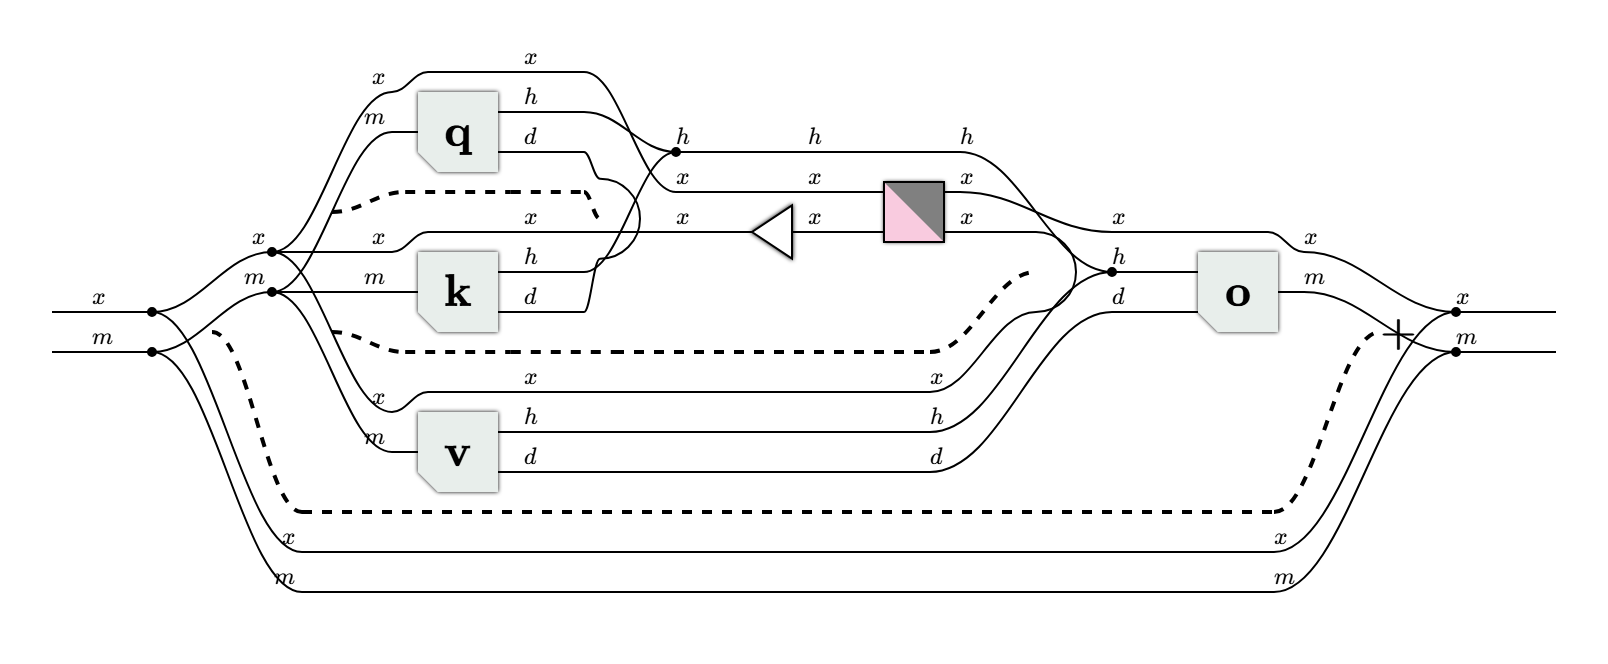

In [4]:
import term_utilities.generate_config as gc
import display.display_config as dpc

## Making the multi-head attention block
## (0, 0) becomes a Rearrangement with mapping \mu: 0 ↦ 0, 1 ↦ 0
def resnet[B: cat.Datatype, A: cat.Axis](target: cat.BroadcastedCategory[B, A]):
    return (0, 0) @ target @ ops.AdditionOp.template()

Lq, Lk, Lv = [ops.Linear.template('m', 2, name) for name in ['q', 'k', 'v']]
Lo = ops.Linear.template(2, 'm', 'o')
attention_linears = (0, 0, 0) @ (Lq * Lk * Lv) @ attention_core @ Lo
attention_block = resnet(attention_linears)
await print_term(attention_block)

# 1.1.2 Applying the configuration;

Scanning for Free Numerics,
Name|Type       |Bucket  |Assignment
x   |FreeNumeric|        |          
m   |FreeNumeric|        |          
h   |FreeNumeric|        |          
d   |FreeNumeric|        |          
d   |FreeNumeric|        |          

Applying Configuration,
Name|Type       |Bucket  |Assignment          
x   |FreeNumeric|        |                    
m   |FreeNumeric|2       |Integer(_value=1024)
h   |FreeNumeric|1       |Integer(_value=8)   
d   |FreeNumeric|0       |Integer(_value=128) 
d   |FreeNumeric|0       |Integer(_value=128) 
Requesting render from server...
Received from server: {"msgType": "Connected"}


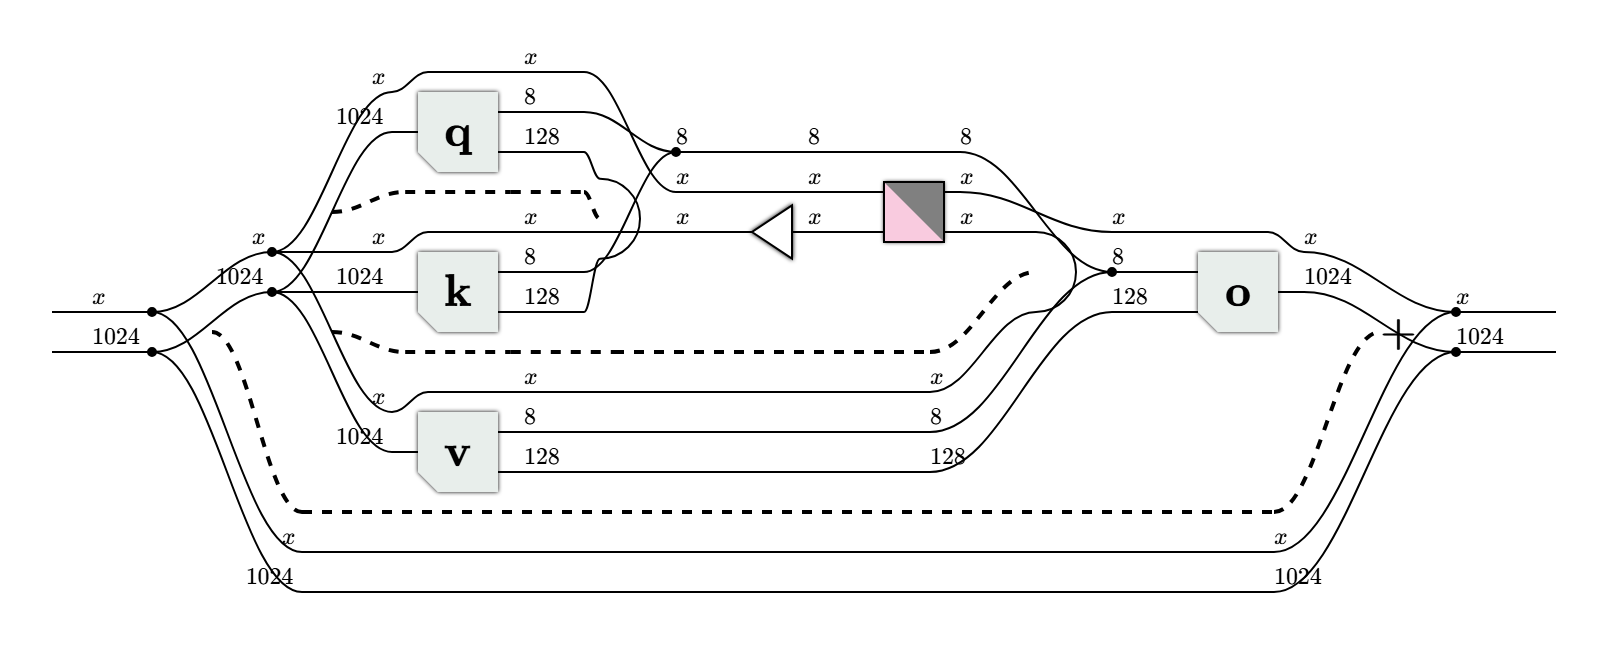

In [5]:
print('Scanning for Free Numerics,')
config = gc.NumericConfig.template(attention_block)
print(dpc.display_config(config))

print('\nApplying Configuration,')
ATTN_INNER, ATTN_HEAD, MODEL_DIM = (128, 8, 1024)
config.assign_values(d=ATTN_INNER, h=ATTN_HEAD, m=MODEL_DIM)
print(dpc.display_config(config))
configured_attention = config.apply_context(attention_block)

await print_term(configured_attention)

# 1.1.3 PyTorch compilation

In [6]:
import torch
import torch_compile.torch_compile as tc
import einops
from torch_compile.torch_utilities import Multilinear

## An implemented torch module
def weighted_triangular_lower(x: torch.Tensor) -> torch.Tensor:
    trilled = torch.tril(x)
    return trilled / (torch.sum(trilled, dim=-1, keepdim=True) + 1e-8)

class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d: int, h: int, m: int):
        super().__init__()
        self.d, self.h, self.m = d, h, m
        self.Lq, self.Lk, self.Lv = [Multilinear(m, (h, d), bias=False) for _ in range(3)]
        self.Lo = Multilinear((h, d), m, bias=False)

    def forward(self, x):
        q, k, v = (self.Lq(x), self.Lk(x), self.Lv(x))
        qk = einops.einsum(q, k, '... q h d, ... x h d -> ... h q x')
        qk = torch.softmax(qk, dim=-1)
        qk = weighted_triangular_lower(qk)
        qkv = einops.einsum(qk, v, '... h q x, ... x h d -> ... q h d')
        return self.Lo(qkv) + x
    
module_nn = MultiHeadAttention(ATTN_INNER, ATTN_HEAD, MODEL_DIM)
module_cat = tc.ConstructedModule.construct(configured_attention)

with torch.inference_mode():
    for p0, p1 in zip(module_nn.parameters(), module_cat.parameters()):
        p0.data = p1.data.clone()

    BATCH_SIZE, SEQ_LEN = 8, 16
    dummy_data = torch.randn(BATCH_SIZE, SEQ_LEN, MODEL_DIM)
    
    y_cat = module_cat(dummy_data)[0]
    y_nn = module_nn(dummy_data)
    print(torch.equal(y_cat, y_nn))

True


# 1.1.4 Graph Processing

Requesting render from server...
Received from server: {"msgType": "Connected"}


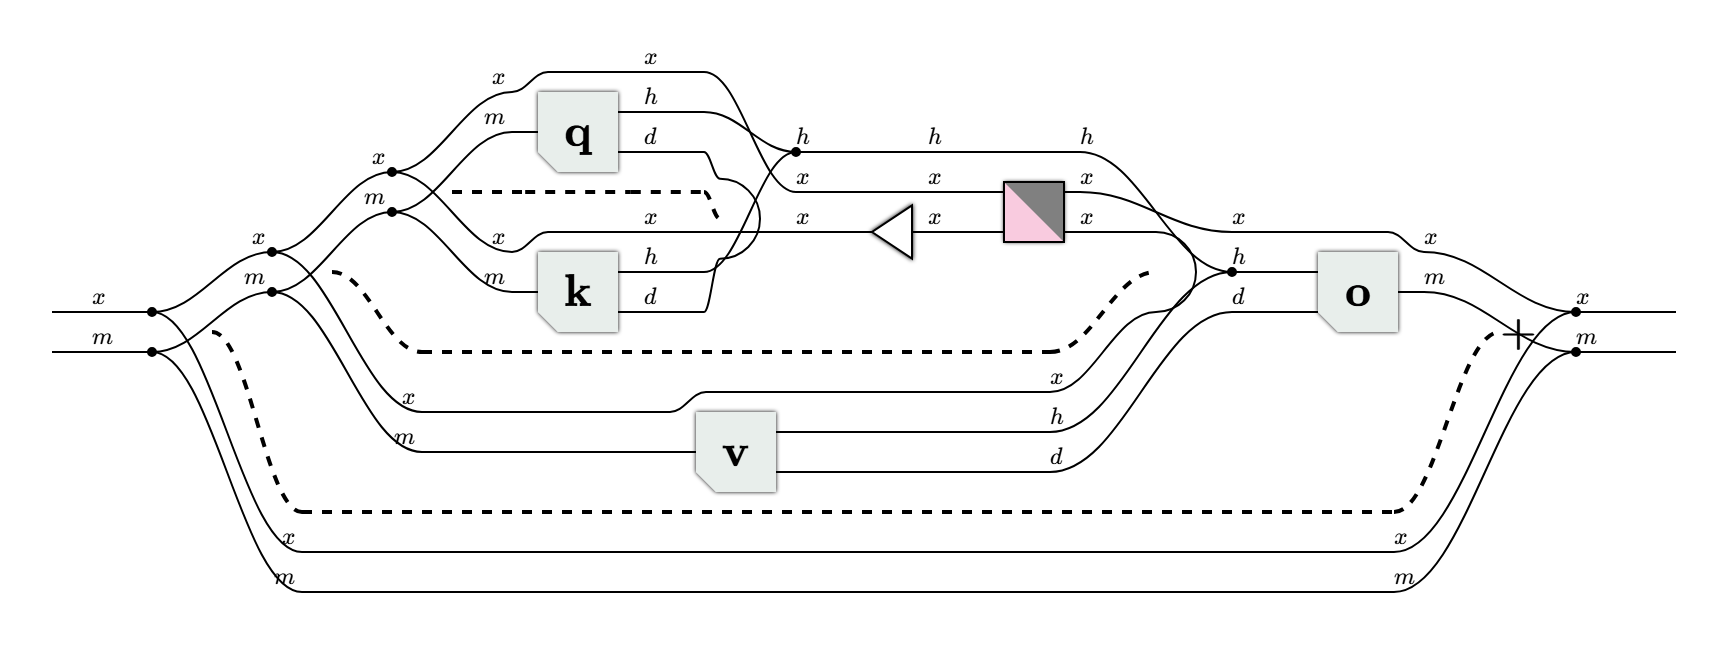

In [7]:
import graphs.Hypergraph as hg
import graphs.Hypergraph2Morphism as h2m
graph = hg.StructuredHypergraph.from_morphism(attention_block)
reconstructed = h2m.hypergraph_to_morphism(graph)
await print_term(reconstructed)